# 03 — Modeling & Fair Comparison

Baseline → XGBoost (3 loss) → LightGBM → LSTM → uji ensemble. **Split & metrik identik**;
semua dievaluasi pada *common test set* (loop lengkap, tempat Loop MAE terdefinisi), dalam
detik (`expm1`). Logika di `src/models.py`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from src.data import load_raw, add_gap_flag, clean_outliers, time_split, sequence_ready
from src import features as F, models as Mdl, metrics as M
import torch; torch.set_num_threads(8)

clean, _ = clean_outliers(add_gap_flag(load_raw()), verbose=False)
feat = F.build_base_features(clean)
tr, te = time_split(feat)
tr, te = F.add_dwell_feature(tr, te)              # D12: dwell terminal feature
art = F.fit_feature_artifacts(tr); tr = F.transform_with_artifacts(tr, art); te = F.transform_with_artifacts(te, art)  # D13 bus_encoded di sini
te_c = sequence_ready(te)
Xtr, ytr_log, _ = Mdl.make_xy(tr); Xc, _, yc = Mdl.make_xy(te_c)
print(f"train={len(tr)} rows | common test = {te_c['no_do'].nunique()} loops")

train=258590 rows | common test = 2327 loops


## Baseline + tabular (XGBoost 3 objective + LightGBM)
Loss diuji di ruang log: MSE (≈ relative error), Huber (robust), MAE (L1).

In [2]:
rows = [Mdl.evaluate("Baseline (seg,hour mean)", yc, F.predict_baseline(te_c, art["baseline_model"]), te_c)]
for obj, label, extra in [("reg:squarederror", "XGBoost (MSE-log)", {}),
                          ("reg:pseudohubererror", "XGBoost (Huber-log)", {"huber_slope": 0.5, "base_score": float(ytr_log.mean())}),
                          ("reg:absoluteerror", "XGBoost (MAE-log)", {})]:
    m = Mdl.train_xgb(Xtr, ytr_log, objective=obj, **extra)
    rows.append(Mdl.evaluate(label, yc, Mdl.predict_sec(m, Xc), te_c))
ml = Mdl.train_lgbm(Xtr, ytr_log)
rows.append(Mdl.evaluate("LightGBM (MSE-log)", yc, Mdl.predict_sec(ml, Xc), te_c))
Mdl.compare_table(rows)

,Model,MAE_s,RMSE_s,MAPE_seg_%,LoopMAE_s,n_loops
0,XGBoost (MAE-log),31.81,93.95,23.63,258.83,2325
1,XGBoost (MSE-log),32.40,94.31,23.57,266.89,2325
2,LightGBM (MSE-log),32.27,93.11,23.55,267.40,2325
3,XGBoost (Huber-log),32.27,96.08,23.66,267.78,2325
4,"Baseline (seg,hour mean)",50.79,125.29,46.12,510.34,2325


## LSTM (PyTorch; sekuens per `no_do`, hanya loop lengkap)
TF 2.16/keras 3 crash di NumPy 2.x → PyTorch (D0). Loop pendek (~20 langkah) → sinyal tipis.

In [3]:
tr_c = sequence_ready(tr)
Xcols = tr_c[F.FEATURE_COLS].copy(); Xcols["is_gap_suspected"] = Xcols["is_gap_suspected"].astype(int)
scaler = StandardScaler().fit(Xcols.to_numpy(float))
max_len = Mdl.lstm_max_len(tr_c, te_c)
Xl, yl, ll, _ = Mdl.build_lstm_arrays(tr_c, F.FEATURE_COLS, max_len, scaler)
lstm = Mdl.train_lstm(Mdl.build_lstm_model(Xl.shape[2]), Xl, yl, ll, epochs=12, verbose=False)
d_te, lstm_te = Mdl.lstm_predict_sec(lstm, te_c, F.FEATURE_COLS, max_len, scaler)
rows.append(Mdl.evaluate("LSTM (Huber-log)", d_te["traveling_time_sec"].values, lstm_te, d_te))
Mdl.compare_table(rows)

,Model,MAE_s,RMSE_s,MAPE_seg_%,LoopMAE_s,n_loops
0,XGBoost (MAE-log),31.81,93.95,23.63,258.83,2325
1,XGBoost (MSE-log),32.40,94.31,23.57,266.89,2325
2,LightGBM (MSE-log),32.27,93.11,23.55,267.40,2325
3,XGBoost (Huber-log),32.27,96.08,23.66,267.78,2325
4,LSTM (Huber-log),41.00,125.14,30.51,368.54,2325
5,"Baseline (seg,hour mean)",50.79,125.29,46.12,510.34,2325


## Uji ensemble XGB+LSTM (bobot di-fit di VALIDATION, bukan test)
Stacking/weighted hanya sah bila base saling melengkapi. Di sini error berkorelasi.

In [4]:
vcut = pd.Timestamp("2026-02-19"); ls = tr.groupby("no_do")["departure_time"].transform("min")
base_tr, val = tr[ls < vcut], tr[ls >= vcut]; val_c = sequence_ready(val)
Xb, yb, _ = Mdl.make_xy(base_tr); xgb_b = Mdl.train_xgb(Xb, yb, objective="reg:absoluteerror")
btr_c = sequence_ready(base_tr)
Xc2 = btr_c[F.FEATURE_COLS].copy(); Xc2["is_gap_suspected"] = Xc2["is_gap_suspected"].astype(int)
sc = StandardScaler().fit(Xc2.to_numpy(float)); mln = Mdl.lstm_max_len(btr_c, val_c, te_c)
Xl2, yl2, ll2, _ = Mdl.build_lstm_arrays(btr_c, F.FEATURE_COLS, mln, sc)
lstm_b = Mdl.train_lstm(Mdl.build_lstm_model(Xl2.shape[2]), Xl2, yl2, ll2, epochs=12, verbose=False)
dv, lv = Mdl.lstm_predict_sec(lstm_b, val_c, F.FEATURE_COLS, mln, sc)
dt, lt = Mdl.lstm_predict_sec(lstm_b, te_c, F.FEATURE_COLS, mln, sc)
xv = Mdl.predict_sec(xgb_b, Mdl.make_xy(dv)[0]); xt = Mdl.predict_sec(xgb_b, Mdl.make_xy(dt)[0])
lmf = lambda d, p: M.loop_mae(d.assign(_p=p), "traveling_time_sec", "_p")[0]
w = float(min(np.linspace(0, 1, 21), key=lambda w: lmf(dv, w * xv + (1 - w) * lv)))
yt = dt["traveling_time_sec"].values
print(f"bobot dari validation: XGB w={w:.2f}")
Mdl.compare_table([Mdl.evaluate("XGBoost (base_tr)", yt, xt, dt),
                   Mdl.evaluate("LSTM (base_tr)", yt, lt, dt),
                   Mdl.evaluate(f"Ensemble convex (w={w:.2f})", yt, w * xt + (1 - w) * lt, dt)])

bobot dari validation: XGB w=0.95


,Model,MAE_s,RMSE_s,MAPE_seg_%,LoopMAE_s,n_loops
0,XGBoost (base_tr),31.99,93.89,23.97,258.08,2325
1,Ensemble convex (w=0.95),32.06,94.42,24.08,259.76,2325
2,LSTM (base_tr),40.28,123.83,29.44,374.06,2325


## Visualisasi Perbandingan Model

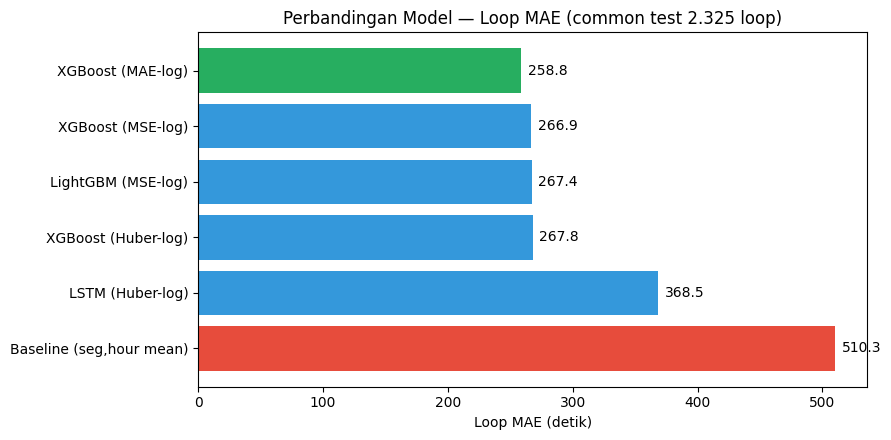

In [5]:
import matplotlib.pyplot as plt
tbl = Mdl.compare_table(rows).sort_values("LoopMAE_s")
colors = ['#e74c3c' if 'Baseline' in m else '#27ae60' if m.startswith('XGBoost (MAE-log)') else '#3498db' for m in tbl['Model']]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(tbl['Model'], tbl['LoopMAE_s'], color=colors)
for b, v in zip(bars, tbl['LoopMAE_s']):
    ax.text(v+5, b.get_y()+b.get_height()/2, f"{v:.1f}", va='center', fontsize=10)
ax.set_xlabel("Loop MAE (detik)"); ax.set_title("Perbandingan Model — Loop MAE (common test 2.325 loop)")
ax.invert_yaxis(); fig.tight_layout(); plt.show()

## Kesimpulan (D7/D8)
**XGBoost (MAE-log) = terbaik, Loop MAE 258.8s (lift 49.3% vs baseline 510.3).** Setelah
menambahkan 2 fitur (`time_since_prev_arrival_sec` + `bus_encoded`, D12/D13), Loop MAE turun
dari 328.8 → 258.8 = **−21.3% improvement** dari kondisi sebelumnya.
LSTM lebih lemah (loop pendek + error berkorelasi). Ensemble diuji sebelumnya & **kalah**
dari XGBoost tunggal → **pilih XGBoost tunggal**: latensi 1.5 ms/loop, 1 artifact `.json`,
retrain detik. Pemilihan tetap konsisten dengan kriteria simpler + faster + competitive.